In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf 

In [2]:
start = '2015-01-01'
end = '2025-01-01'
df = yf.download('AAPL' , start = start ,end = end)
df.head()
df.tail()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-12-24,256.560852,256.570768,253.669307,253.868050,23234700
2024-12-26,257.375610,258.448771,255.994450,256.550893,27237100
2024-12-27,253.967377,257.057649,251.453440,256.193146,42355300
2024-12-30,250.598907,251.890657,249.158116,250.628716,35557500
2024-12-31,248.830231,251.672075,247.846510,250.837411,39480700


In [3]:
df = df.reset_index()
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2015-01-02,24.192606,24.659508,23.754470,24.648443,212818400
1,2015-01-05,23.511065,24.042138,23.325190,23.962477,257142000
2,2015-01-06,23.513273,23.772171,23.152585,23.575232,263188400
3,2015-01-07,23.842979,23.942555,23.610634,23.721274,160423600
4,2015-01-08,24.759079,24.816612,24.053194,24.170474,237458000


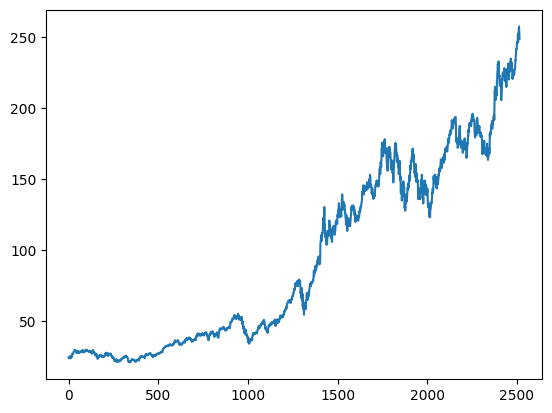

In [4]:
plt.plot(df.Close)

In [5]:
ma100 = df.Close.rolling(100).mean()
ma100

Ticker,AAPL
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
2511,228.152032
2512,228.651060
2513,229.136231
2514,229.562039


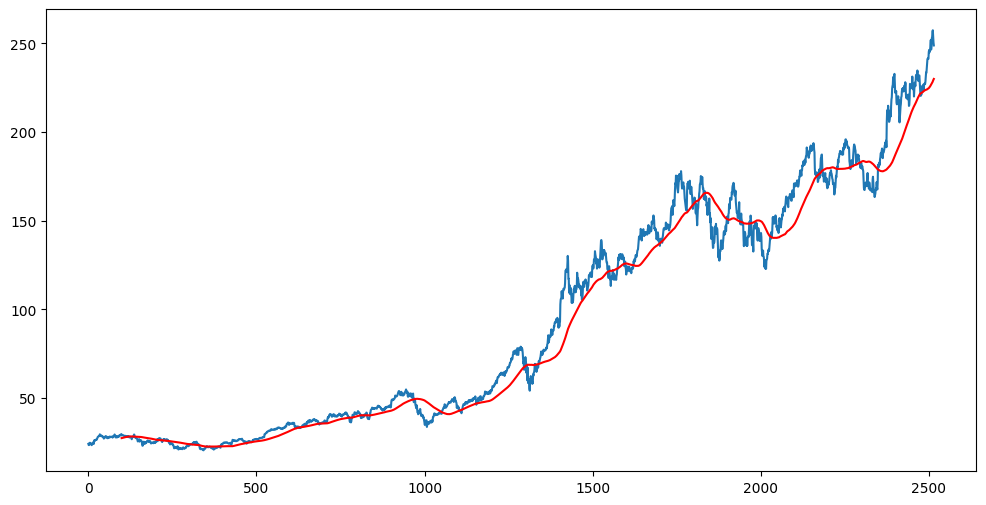

In [6]:
plt.figure(figsize = (12 , 6))
plt.plot(df.Close)
plt.plot(ma100 , 'r')


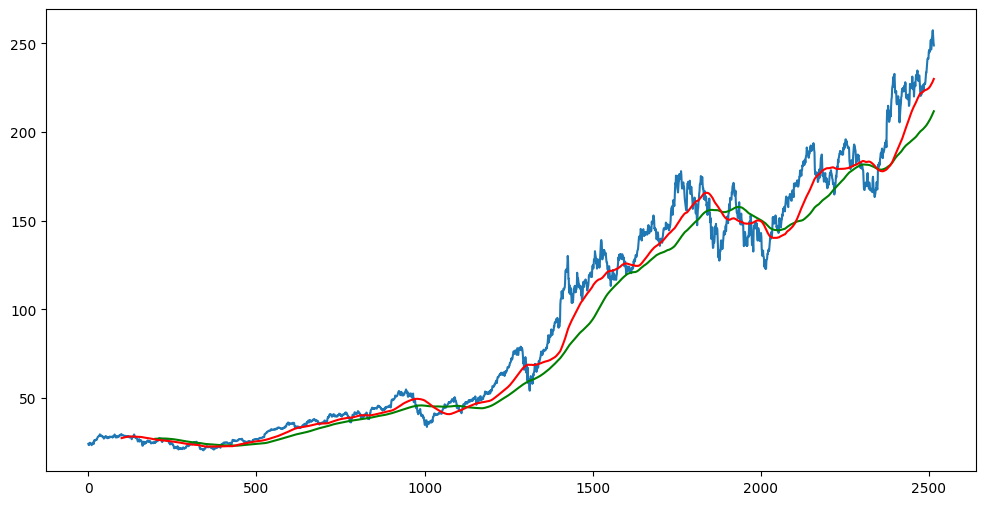

In [7]:
ma200 = df.Close.rolling(200).mean()

plt.figure(figsize = (12 , 6))
plt.plot(df.Close)
plt.plot(ma200 , 'g')
plt.plot(ma100 , 'r')



In [8]:
df.shape

(2516, 6)

In [9]:
# Splitting Data into Training and Testing

data_training = pd.DataFrame(df['Close'][0:int(len(df)*0.70)])
data_testing = pd.DataFrame(df['Close'][int(len(df)*0.70): int(len(df))])

print(data_training.shape)
print(data_testing.shape)

(1761, 1)
(755, 1)


In [10]:
data_training.head()

Ticker,AAPL
0,24.192606
1,23.511065
2,23.513273
3,23.842979
4,24.759079


In [11]:
data_testing.head()

Ticker,AAPL
1761,174.214920
1762,173.598999
1763,177.939697
1764,175.681381
1765,171.008255


In [12]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range = (0,1))

In [13]:
data_training_array = scaler.fit_transform(data_training)
data_training_array

array([[0.0232884 ],
       [0.01891201],
       [0.0189262 ],
       ...,
       [1.        ],
       [0.9934714 ],
       [0.99403636]], shape=(1761, 1))

In [14]:
x_train = []
y_train = []

for i in range(100, len(data_training_array)):
    x_train.append(data_training_array[i-100:i])
    y_train.append(data_training_array[i, 0])

x_train = np.array(x_train)
y_train = np.array(y_train)

In [15]:
x_train.shape

(1661, 100, 1)

In [16]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout


In [17]:
# Model
model = Sequential()

# 1st LSTM layer
model.add(LSTM(units=50,
               activation='tanh',
               return_sequences=True,
               input_shape=(x_train.shape[1], 1)))
model.add(Dropout(0.2))

# 2nd LSTM layer
model.add(LSTM(units=60,
               activation='tanh',
               return_sequences=True))
model.add(Dropout(0.3))

# 3rd LSTM layer
model.add(LSTM(units=80,
               activation='tanh',
               return_sequences=True))
model.add(Dropout(0.4))

# Final LSTM layer (no return_sequences)
model.add(LSTM(units=120,
               activation='tanh'))
model.add(Dropout(0.5))

# Output layer
model.add(Dense(units=1))

C:\Users\Bhoomika Garg\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [18]:
# Compile model
model.compile(optimizer='adam',
              loss='mean_squared_error')

# Train model
model.fit(x_train, y_train, epochs=50)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 72s 688ms/step - loss: 0.0140
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 30s 581ms/step - loss: 0.0044
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 33s 634ms/step - loss: 0.0040
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 31s 587ms/step - loss: 0.0028
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 42s 609ms/step - loss: 0.0026
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 33s 623ms/step - loss: 0.0025
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 30s 576ms/step - loss: 0.0027
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 31s 594ms/step - loss: 0.0026
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 31s 584ms/step - loss: 0.0027
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 40s 561ms/step - loss: 0.0027
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 32s 614ms/step - loss: 0.0029
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 33s 633ms/step - loss: 0.0021
Epoch 13/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 43s 661ms/step - loss: 0.0019
Epoch 14/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 32s 605ms/step - loss: 0.0017
Epoch 15/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 38s 

In [19]:
model.save('keras_model.h5')

In [20]:
past_100_days = data_training.tail(100)

In [23]:
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)

In [25]:
input_data = scaler.fit_transform(final_df)

In [26]:
input_data.shape

(855, 1)

In [30]:
data_testing_array = scaler.fit_transform(data_testing)
data_testing_array

array([[3.81438451e-01],
       [3.76857139e-01],
       [4.09143897e-01],
       [3.92346207e-01],
       [3.57586801e-01],
       [3.36353303e-01],
       [3.37589741e-01],
       [3.37734790e-01],
       [3.58750260e-01],
       [3.62022723e-01],
       [3.37734790e-01],
       [3.44134213e-01],
       [3.20355428e-01],
       [2.94395001e-01],
       [2.81887276e-01],
       [2.66616577e-01],
       [2.60871919e-01],
       [2.47491628e-01],
       [2.46837431e-01],
       [2.43419578e-01],
       [3.24209450e-01],
       [3.56568959e-01],
       [3.55332748e-01],
       [3.64276890e-01],
       [3.42898002e-01],
       [3.40786388e-01],
       [3.35471203e-01],
       [3.58552435e-01],
       [3.69109825e-01],
       [3.38820277e-01],
       [3.13482382e-01],
       [3.15230010e-01],
       [3.43698724e-01],
       [3.41951322e-01],
       [3.15230010e-01],
       [3.03725600e-01],
       [2.82028012e-01],
       [2.51083472e-01],
       [2.70524056e-01],
       [2.85887028e-01],


In [34]:
x_test = []
y_test = []

for i in range(100, data_testing_array.shape[0]):
    x_test.append(data_testing_array[i-100:i])
    y_test.append(data_testing_array[i, 0])

x_test = np.array(x_test)
y_test = np.array(y_test)

In [35]:
y_predicted = model.predict(x_test)
y_predicted.shape

21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 334ms/step


(655, 1)

In [36]:
scaler.scale_

array([0.00743815])

In [37]:
scale_factor = 1/0.00743815
y_predicted = y_predicted*scale_factor
y_test = y_test*scale_factor

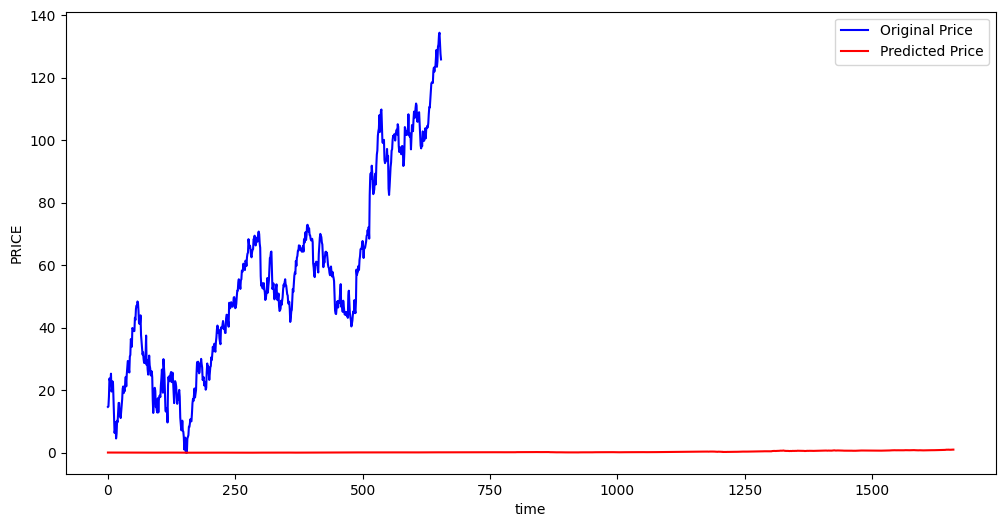

In [39]:
plt.figure(figsize = (12 , 6))
plt.plot(y_test , 'b' , label = 'Original Price' )
plt.plot(y_train , 'r' , label = 'Predicted Price' )
plt.xlabel("time")
plt.ylabel("PRICE")
plt.legend()
plt.show()